# Assignment 2 - Computer Vision

This assignment is split in two parts:
- Part A: Analyse pre-trained CNN models architecture and compare performance on Food101 dataset
- Part B: Fine-tune selected pretrained CNN model on Food101 dataset

## Dataset:
You will be working on the Food101 dataset. This dataset consists of 101 food categories, with 101,000 images. For each class, 250 manually reviewed test images are provided as well as 750 training images. All images were rescaled to have a maximum side length of 512 pixels.

The dataset can be downloaded from here: http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz

## Description:

Part A: Transfer Learning
In Part A, your task is to analyse the architectural difference between 3 CNN models and perform transfer learning on them to accurately predict 101 different classes from the Food101 Dataset.

You will have to perform transfer learning (using the weights obtained from the ImageNet dataset) on the following 3 pre-trained models and compare their results:
* GoogLeNet
* MobileNet V3
* Resnet

For each model, you will:
* Replace the Model Head: Remove the existing head (the final classification layers) and replace it with a new head consisting of three fully connected layers. The third fully connected layer will be the final prediction layer.
* Freeze Pre-Trained Layers: Keep all the pre-trained layers frozen so that only the new head is trained on the Food101 data.

## Part B: Fine Tuning
In Part B, your task is to pick the best pre-trained model from part A and fine-tune it on the Food101 Dataset.

You will need to experiment unfreezing on at least 2 different layers of the model.

## Submission:
You will submit a zip file containing your python notebooks and report.

The zip file needs to contain the following files:
* Part A Notebook (ipynb files)
* Part B Notebook (ipynb files)
* Report (Word document or PDF)

The report will need to contain at least the following topics:
* Presentation of dataset
* Presentation of the different architectures used for Transfer Learning, their specificities and historical advancement
* Walk-through of transfer learning training process
* Analysis of pre-trained models performance and limitations
* Walk-through of fine-tuning and model training approach
* Analysis of fine-tuned models performance and limitations
* Presentation of remaining issues and recommendations

All assignments need to be submitted before the due date on Canvas. Penalties will be applied for late submission.

## Assessment Criteria:
* Rigour in addressing technical brief in terms of completeness and appropriate coverage of test suite (20%)
* Clear, efficient, concise code appropriately commented (25%)
* Effort and results on model extension component (15%)
* Quality of results including their assessment, interpretation and benchmarking (25%)
* Well written report ensuring format and communication style is context appropriate (15%)

Deadline: 22nd April 2026 23:59, late penalty of 10pt per day.


## Assignment 2
### Notebook preparation


In [ ]:
import pandas as pd
import os
import torch, torchvision
torch.manual_seed(42)


## 2. Data Preparation

[2.1] Download dataset

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

download_dir = '/content/drive/MyDrive/94691/data/'

# Mkdir for data
!mkdir -p {download_dir}

# Change working directory:
os.chdir(download_dir)

Mounted at /content/drive


In [ ]:
# Download data
url = 'http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz'

if not os.path.exists('food-101.tar.gz'):
  # Wget without overriding existing
  !wget --no-clobber {url}

local_dir = '/content/food-101'
if not os.path.exists(local_dir):
   !tar -xzkf food-101.tar.gz -C /content/

# Print number of directories unpacked:
!ls -1 /content/food-101/images/ | wc -l

101


[2.2a] Resize all images once to speed up training


In [ ]:
import os
from PIL import Image
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

src_dir = '/content/food-101/images'
dest_dir = '/content/food-101-256/images'

# Create a list of all image paths
all_files = []
for root, _, files in os.walk(src_dir):
  for f in files:
    if f.endswith('.jpg'):
      # Get relative path (e.g. 'apple_pie/1005649.jpg')
      rel_path = os.path.relpath(os.path.join(root, f), src_dir)
      if not os.path.exists(os.path.join(dest_dir, rel_path)):
        all_files.append(rel_path)

def process_image(rel_path):
    src_path = os.path.join(src_dir, rel_path)
    dest_path = os.path.join(dest_dir, rel_path)

    # Create class subfolder if it doesn't exist
    os.makedirs(os.path.dirname(dest_path), exist_ok=True)

    try:
        with Image.open(src_path) as img:
            img = img.convert('RGB')
            # Calculate new size: shortest edge = 256
            w, h = img.size
            if w < h:
                new_w = 256
                new_h = int(256 * h / w)
            else:
                new_h = 256
                new_w = int(256 * w / h)

            # Resize and save (quality=95 prevents artifacting)
            img = img.resize((new_w, new_h), Image.BILINEAR)
            img.save(dest_path, format='JPEG', quality=95)
    except Exception as e:
        print(f"Error on {rel_path}: {e}")

# Run preprocessing across all CPU cores
if len(all_files) > 0:
  print(f"Processing {len(all_files)} images...")
  with ProcessPoolExecutor(max_workers=os.cpu_count()) as executor:
      list(tqdm(executor.map(process_image, all_files), total=len(all_files)))

print("Finished creating 256x256 dataset!")

Processing 101000 images...


100%|██████████| 101000/101000 [07:25<00:00, 226.53it/s]

Finished creating 256x256 dataset!


[2.2b] Set data loading transforms.

All three target models are internally working with image sizes of 224x224 and will all resize the input to 256x256 internally before cropping to the target size.

To make the best use of our input images which has a longest edge of 512 (either w * 512 or 512 * h, where w and h are <= 512), we will perform a 256x256 random

In [ ]:
from torchvision.transforms import v2

# Define Transforms
train_transforms = torch.nn.Sequential(
    v2.ToImage(),  # Convert to tensor, only needed if you had a PIL image
    v2.ToDtype(torch.uint8, scale=True),  # optional, most input are already uint8 at this point
    # v2.Resize(256), # Already done above
    v2.RandomCrop(224),
    v2.RandomHorizontalFlip(),
    v2.RandomRotation(90),
    # v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # Slight color changes
    v2.ToDtype(torch.float32, scale=True),  # Normalize expects float input
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
)

eval_transforms = torch.nn.Sequential(
    v2.ToImage(),  # Convert to tensor, only needed if you had a PIL image
    v2.ToDtype(torch.uint8, scale=True),  # optional, most input are already uint8 at this point
    # v2.Resize(256), # Already done above
    v2.CenterCrop(224),
    v2.ToDtype(torch.float32, scale=True),  # Normalize expects float
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
)


[2.3] Creata dataset from downloaded image classes/folders


In [ ]:
from torchvision.datasets.folder import default_loader
from torch.utils.data import Dataset

class Food101Split(Dataset):
    def __init__(self, root, split_file, transform=None):
        self.root = root
        self.transform = transform
        self.loader = default_loader

        with open(split_file, 'r') as f:
            entries = [line.strip() for line in f.readlines()]

        # Build class-to-index mapping from folder names
        classes = sorted(set(e.split('/')[0] for e in entries))
        self.class_to_idx = {c: i for i, c in enumerate(classes)}

        self.samples = []
        for entry in entries:
            class_name = entry.split('/')[0]
            path = os.path.join(root, 'images', f'{entry}.jpg')
            self.samples.append((path, self.class_to_idx[class_name]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = self.loader(path)
        if self.transform:
            img = self.transform(img)
        return img, label

meta_dir = os.path.join(local_dir, 'meta')

train_full = Food101Split('/content/food-101-256/', os.path.join(meta_dir, 'train.txt'))
test_dataset = Food101Split('/content/food-101-256/', os.path.join(meta_dir, 'test.txt'))

# Split off a validation set from the training data
train_size = int(0.85 * len(train_full))
val_size = len(train_full) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(train_full, [train_size, val_size])

print(f"Training dataset: {len(train_dataset)}")
print(f"Validation dataset: {len(val_dataset)}")
print(f"Test dataset: {len(test_dataset)}")

Training dataset: 64387
Validation dataset: 11363
Test dataset: 25250


[2.4] Let's print some test images from the dataset

Image label: cup_cakes


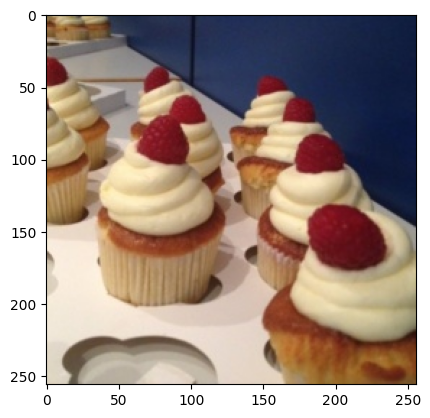

After transform:


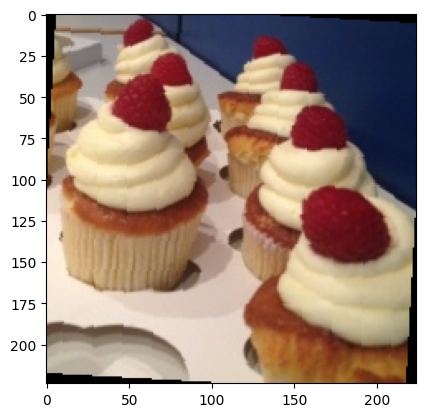

Image label: frozen_yogurt


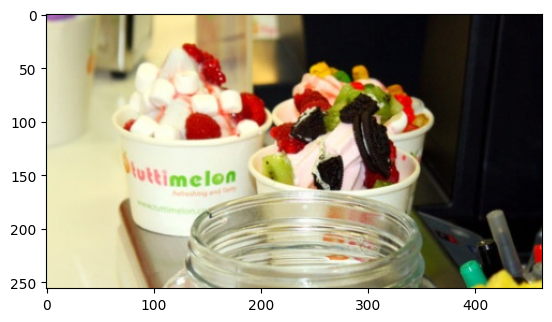

After transform:


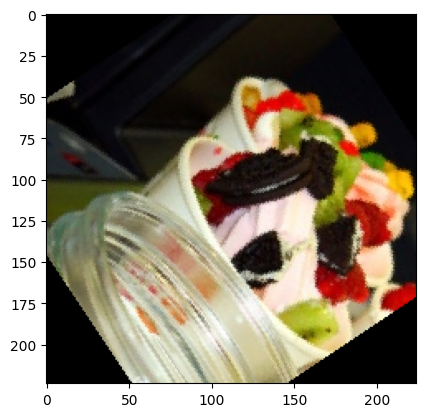

In [ ]:
# Solution
import matplotlib.pyplot as plt
import numpy as np

classes = train_full.class_to_idx  # or build a list from it
class_names = sorted(train_full.class_to_idx.keys())

# Function to show an image
def imshow(img, transform_back):

    if transform_back:
      mean = np.array([0.485, 0.456, 0.406])  # Mean values for normalization
      std = np.array([0.229, 0.224, 0.225])   # Standard deviation values for normalization
      img = img.numpy().transpose((1, 2, 0))  # Transposing the image from (C, H, W) to (H, W, C) for visualization
      img = std * img + mean                  # Applying normalization
      img = np.clip(img, 0, 1)                # Clip to ensure values are in [0, 1] range
    plt.imshow(img)                         # Display the image
    plt.show()                              # Show the plot

for i in range(2):
    idx = np.random.randint(0, len(train_full))
    img, label = train_full[idx]
    class_name = class_names[label]
    # Show image and print label:
    print(f"Image label: {class_name}")
    imshow(img, False)
    print(f"After transform:")
    imshow(train_transforms(img), True)


[2.4b] Understand image dimensions of files more thoroughly by sampling 100 images and plotting the short dimension.

(array([  0.,   0.,   0.,   0.,   0., 100.,   0.,   0.,   0.,   0.]),
 array([255.5, 255.6, 255.7, 255.8, 255.9, 256. , 256.1, 256.2, 256.3,
        256.4, 256.5]),
 <BarContainer object of 10 artists>)

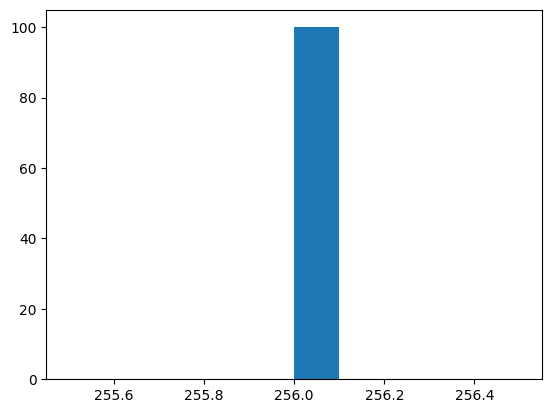

In [ ]:
# Sample 100 random images
short_dims = []

for i in range(100):
  img = train_dataset[int(np.random.rand() * len(train_dataset))][0]

  minimum = min(img.width, img.height)
  short_dims.append(minimum)

# Plot histogram
plt.hist(short_dims, bins=10)

[2.5] Verify the dataset split:

In [ ]:
total_train = len(train_dataset)
total_val = len(val_dataset)
total_test = len(test_dataset)

# Print the total number of training and testing samples
print(f"Size of training set: {total_train}")
print(f"Size of validation set: {total_val}")
print(f"Size of test set: {total_test}")


Size of training set: 64387
Size of validation set: 11363
Size of test set: 25250


# 3. Defining the models
[3.1] Importing

In [ ]:
import torch.nn as nn

[3.2] Loading the models GoogLeNet, MobilNet V3 and Resnet

In [ ]:
# Load GoogLeNet, MobileNet V3, Resnet
googlenet = torchvision.models.googlenet(pretrained=True)
mobilenet_v3 = torchvision.models.mobilenet_v3_large(pretrained=True)
resnet = torchvision.models.resnet50(pretrained=True)

models = [mobilenet_v3, googlenet, resnet]

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get th

[3.3] Let's freeze the models

In [ ]:
for m in models:
  for param in m.parameters():
    param.requires_grad = False

[3.4] Inspect the models

In [ ]:
for m in models:
  print(m)


MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

[3.5] Just print the head of each model

In [ ]:
print("googlenet.fc:")
print(googlenet.fc)

print("\nMobileNet_v3.classifer:")
print(mobilenet_v3.classifier)

print("\nResNet.fc:")
print(resnet.fc)

googlenet.fc:
Linear(in_features=1024, out_features=1000, bias=True)

MobileNet_v3.classifer:
Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=1000, bias=True)
)

ResNet.fc:
Linear(in_features=2048, out_features=1000, bias=True)


[3.5] Replace the head for each model

In [ ]:
# Replace with head with an 3 fully connected layers down to the 101 classes:

# We DO NOT add softmax as a final activation function, because
# CrossEntropyLoss already includes it, and we want argmax anyway
# rather than sampling

googlenet.fc = nn.Sequential(
    nn.Linear(1024, 1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(),
    nn.Dropout(0.25),
    nn.Linear(1024, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 101)
)

mobilenet_v3.classifier = nn.Sequential(
    nn.Linear(960, 1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(),
    nn.Dropout(0.25),
    nn.Linear(1024, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 101)
)

resnet.fc = nn.Sequential(
    nn.Linear(2048, 1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(),
    nn.Dropout(0.25),
    nn.Linear(1024, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 101)
)



# 4. Training and Evaluation of the Model

[4.1] Create a torch device and move to GPU if available

In [ ]:
device_type = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device(device_type)
print(device)

cuda


[4.2] Let's move model to device

In [ ]:
for m in models:
  m.to(device)

[4.3] We are performing multi-class classification, so we need nn.CrossEntropyLoss() as the loss metric. After then Instantiate a torch.optim.Adam() optimizer with the model's parameters and 0.01 as learning rate and save it into a variable called optimizer


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizers = [torch.optim.Adam(filter(lambda p: p.requires_grad, m.parameters()), lr=0.01) for m in models]

[4.4] Let's introduce a custom class called Customcallback to control the behaviours of the training. This class offers the following functionalities:

- Monitor the training
- Adjusting learning rates
- Early stopping

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

class CustomCallback:
  def __init__(self, early_stop_patience, reduce_lr_factor, reduce_lr_patience, reduce_lr_min_lr, checkpoint_path='checkpoint.pth'):

    # Parameters for early stopping and learning rate reduction
    self.early_stop_patience = early_stop_patience    # Patience for early stopping
    self.reduce_lr_factor = reduce_lr_factor          # Factor by which to reduce learning rate
    self.reduce_lr_patience = reduce_lr_patience      # Patience for reducing learning rate
    self.reduce_lr_min_lr = reduce_lr_min_lr          # Minimum learning rate
    self.checkpoint_path = checkpoint_path            # Path to save model checkpoints

    self.early_stop_counter = 0                       # Counter to track epochs without improvement
    self.best_val_loss = float('inf')                 # Best validation loss

    self.optimizer = None                             # Placeholder for the optimizer
    self.scheduler = None                             # Placeholder for the LR scheduler

  def set_optimizer(self, optimizer):
    self.optimizer = optimizer                        # Set optimizer for training

  def on_epoch_end(self, epoch, val_loss):
    # Early Stopping: Check if the validation loss improved
    if val_loss < self.best_val_loss:
        self.best_val_loss = val_loss
        self.early_stop_counter = 0                   # Reset counter if improvement is seen

        if self.model is not None:
            torch.save(self.model.state_dict(), self.checkpoint_path)
            print(f"    ! Validation loss improved to {val_loss:.4f}! Saved best model to {self.checkpoint_path}")

    else:
        self.early_stop_counter += 1                  # Increment counter if no improvement

    # Trigger early stopping if no improvement for a defined number of epochs
    if self.early_stop_counter >= self.early_stop_patience:
        print("Early stopping triggered!")
        return True                                   #  Return True to signal stopping training

    # Adjust the learning rate if a plateau in validation loss is detected
    if self.scheduler is not None:
        self.scheduler.step(val_loss)                 # Adjust learning rate based on validation loss

    return False  # Continue training if conditions are not met

  def on_train_begin(self):
    # Initialize the ReduceLROnPlateau scheduler with the optimizer and parameters.
    self.scheduler = ReduceLROnPlateau(self.optimizer, mode='min', factor=self.reduce_lr_factor,patience=self.reduce_lr_patience, min_lr=self.reduce_lr_min_lr)

  def on_train_end(self):
    pass                  # Additional cleanup can be done here if needed

  def set_model(self, model):
    self.model = model    # Store the model reference

[4.5] Use some data augmentation during training



In [ ]:
from torch.utils.data import DataLoader, Dataset
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True # At least one image crashed

class DatasetWrapper(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

# Trying to use GPU transforms:

cpu_train_transforms = torch.nn.Sequential(
    v2.ToImage(),                   # Converts PIL to uint8 Tensor
    # v2.Resize(256, antialias=True), # Uniform size # Done once during preprocessing above
    v2.RandomCrop(224),             # Uniform size
    # Notice we DO NOT convert to float32 here. We keep it as uint8 to save memory bandwidth!
)

cpu_eval_transforms = torch.nn.Sequential(
    v2.ToImage(),
    # v2.Resize(256, antialias=True), # Done once during preprocessing above
    v2.CenterCrop(224),
)

# Replace your old DatasetWrapper with this:
train_dataset_augmented = DatasetWrapper(train_dataset, transform=cpu_train_transforms)
val_dataset_clean = DatasetWrapper(val_dataset, transform=cpu_eval_transforms)
test_dataset_clean = DatasetWrapper(test_dataset, transform=cpu_eval_transforms)

# 2. GPU Transforms: Define the heavy mathematical operations here
gpu_train_transforms = torch.nn.Sequential(
    v2.RandomHorizontalFlip(),
    v2.RandomRotation(90),
    v2.ToDtype(torch.float32, scale=True), # GPU converts uint8 -> float32 instantly
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
).to(device)

gpu_eval_transforms = torch.nn.Sequential(
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
).to(device)

# Move these transforms to the GPU
gpu_train_transforms = gpu_train_transforms.to(device)
gpu_eval_transforms = gpu_eval_transforms.to(device)

#train_dataset_augmented = DatasetWrapper(train_dataset, transform=train_transforms)
#val_dataset_clean = DatasetWrapper(val_dataset, transform=eval_transforms)
#test_dataset_clean = DatasetWrapper(test_dataset, transform=eval_transforms)

batch_size = 128
num_workers = os.cpu_count() # Use number of CPU cores for parallel data loading
print(num_workers)

train_loader = DataLoader(train_dataset_augmented, batch_size=batch_size, num_workers=num_workers,
    shuffle=True,
    pin_memory=True,
    persistent_workers=False)
val_loader = DataLoader(val_dataset_clean, batch_size=batch_size, num_workers=num_workers,
    shuffle=True,
    pin_memory=True,
    persistent_workers=False)
test_loader = DataLoader(test_dataset_clean, batch_size=batch_size, num_workers=num_workers,
    shuffle=True,
    pin_memory=True,
    persistent_workers=False) # Crashed with True


2


[4.6] Define helper methods to train, validation and plot

In [ ]:
from tqdm import tqdm

def trainOneEpoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    # Progress bar for the epoch
    pbar = tqdm(dataloader, desc="Training", leave=False)

    for images, labels in pbar:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        images = gpu_train_transforms(images)

        optimizer.zero_grad(set_to_none=True)

        # Simple forward pass (works for ResNet, VGG, and GoogLeNet without aux)
        outputs = model(images)

        # Check:
        if hasattr(outputs, 'logits'):
          outputs = outputs.logits

        # Calculate loss
        loss = criterion(outputs, labels.long())

        # Backward and optimize
        loss.backward()
        optimizer.step()

        # Track metrics
        running_loss += loss.item()
        predicted = torch.argmax(outputs, dim=1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

        # Update progress bar with real-time stats
        current_acc = correct_train / total_train
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{current_acc:.2%}")

    # Calculate final epoch averages
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct_train / total_train

    return epoch_loss, epoch_acc

def validateOneEpoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_val = 0
    total_val = 0

    # Wrap dataloader in tqdm
    pbar = tqdm(dataloader, desc="Validating", leave=False)

    with torch.no_grad():
        for images, labels in pbar:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            images = gpu_eval_transforms(images)

            outputs = model(images)

            loss = criterion(outputs, labels.long())
            running_loss += loss.item()

            predicted = torch.argmax(outputs, dim=1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)

            # Update progress bar
            current_acc = correct_val / total_val
            pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{current_acc:.2%}")

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct_val / total_val
    return epoch_loss, epoch_acc

def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, model_name):
    epochs = range(1, len(train_losses) + 1)

    # Create a figure with 2 subplots side-by-side
    plt.figure(figsize=(12, 4))

    # Plot 1: Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Training Loss', marker='o')
    plt.plot(epochs, val_losses, label='Validation Loss', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{model_name} - Losses')
    plt.legend()
    plt.grid(True)

    # Plot 2: Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label='Training Accuracy', marker='o')
    plt.plot(epochs, val_accuracies, label='Validation Accuracy', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name} - Accuracies')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

[4.7] Define training and eval methods and hyperparameters



Starting Training for MobileNetV3


    ! Validation loss improved to 2.3582! Saved best model to /content/drive/MyDrive/94691/models-15-epochs/MobileNetV3_best_food101.pth
Epoch [1/20] | Train Loss: 2.9387 | Train Acc: 30.09% | Val Loss: 2.3582 | Val Acc: 41.54% | LR: 0.010000


    ! Validation loss improved to 2.1690! Saved best model to /content/drive/MyDrive/94691/models-15-epochs/MobileNetV3_best_food101.pth
Epoch [2/20] | Train Loss: 2.5020 | Train Acc: 38.50% | Val Loss: 2.1690 | Val Acc: 45.82% | LR: 0.010000


    ! Validation loss improved to 2.1005! Saved best model to /content/drive/MyDrive/94691/models-15-epochs/MobileNetV3_best_food101.pth
Epoch [3/20] | Train Loss: 2.4000 | Train Acc: 40.87% | Val Loss: 2.1005 | Val Acc: 47.31% | LR: 0.010000


    ! Validation loss improved to 2.0756! Saved best model to /content/drive/MyDrive/94691/models-15-epochs/MobileNetV3_best_food101.pth
Epoch [4/20] | Train Loss: 2.3254 | Train Acc: 42.56% | Val Loss: 2.0756 | Val Acc: 48.25% | LR: 0.010000


...

    ! Validation loss improved to 1.7775! Saved best model to /content/drive/MyDrive/94691/models-15-epochs/MobileNetV3_best_food101.pth
Epoch [16/20] | Train Loss: 1.7696 | Train Acc: 54.65% | Val Loss: 1.7775 | Val Acc: 55.31% | LR: 0.000400


    ! Validation loss improved to 1.7720! Saved best model to /content/drive/MyDrive/94691/models-15-epochs/MobileNetV3_best_food101.pth
Epoch [17/20] | Train Loss: 1.7636 | Train Acc: 54.46% | Val Loss: 1.7720 | Val Acc: 55.44% | LR: 0.000400


Epoch [18/20] | Train Loss: 1.7620 | Train Acc: 54.55% | Val Loss: 1.7734 | Val Acc: 55.12% | LR: 0.000400


Epoch [19/20] | Train Loss: 1.7500 | Train Acc: 54.73% | Val Loss: 1.7744 | Val Acc: 54.97% | LR: 0.000080


    ! Validation loss improved to 1.7671! Saved best model to /content/drive/MyDrive/94691/models-15-epochs/MobileNetV3_best_food101.pth
Epoch [20/20] | Train Loss: 1.7361 | Train Acc: 55.05% | Val Loss: 1.7671 | Val Acc: 55.38% | LR: 0.000080


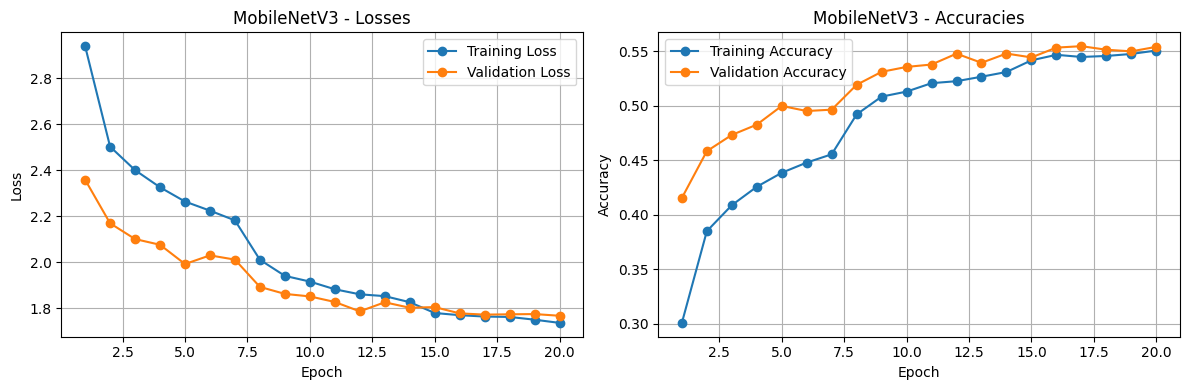


Loading best MobileNetV3 weights from epoch with lowest val_loss...
Evaluating MobileNetV3 on Test Dataset...


--> Test Loss: 1.5130 | Test Acc: 60.11%


Starting Training for GoogLeNet


    ! Validation loss improved to 2.6995! Saved best model to /content/drive/MyDrive/94691/models-15-epochs/GoogLeNet_best_food101.pth
Epoch [1/20] | Train Loss: 3.2790 | Train Acc: 23.71% | Val Loss: 2.6995 | Val Acc: 34.29% | LR: 0.010000


    ! Validation loss improved to 2.6596! Saved best model to /content/drive/MyDrive/94691/models-15-epochs/GoogLeNet_best_food101.pth
Epoch [2/20] | Train Loss: 2.9590 | Train Acc: 29.31% | Val Loss: 2.6596 | Val Acc: 34.76% | LR: 0.010000


    ! Validation loss improved to 2.5621! Saved best model to /content/drive/MyDrive/94691/models-15-epochs/GoogLeNet_best_food101.pth
Epoch [3/20] | Train Loss: 2.8761 | Train Acc: 31.01% | Val Loss: 2.5621 | Val Acc: 37.14% | LR: 0.010000


...

Epoch [16/20] | Train Loss: 2.4816 | Train Acc: 38.96% | Val Loss: 2.3641 | Val Acc: 40.74% | LR: 0.000080


    ! Validation loss improved to 2.3121! Saved best model to /content/drive/MyDrive/94691/models-15-epochs/GoogLeNet_best_food101.pth
Epoch [17/20] | Train Loss: 2.4867 | Train Acc: 38.70% | Val Loss: 2.3121 | Val Acc: 41.81% | LR: 0.000080


    ! Validation loss improved to 2.3095! Saved best model to /content/drive/MyDrive/94691/models-15-epochs/GoogLeNet_best_food101.pth
Epoch [18/20] | Train Loss: 2.4624 | Train Acc: 39.27% | Val Loss: 2.3095 | Val Acc: 42.12% | LR: 0.000080


Epoch [19/20] | Train Loss: 2.4721 | Train Acc: 39.06% | Val Loss: 2.3447 | Val Acc: 41.14% | LR: 0.000080


    ! Validation loss improved to 2.2465! Saved best model to /content/drive/MyDrive/94691/models-15-epochs/GoogLeNet_best_food101.pth
Epoch [20/20] | Train Loss: 2.4695 | Train Acc: 39.52% | Val Loss: 2.2465 | Val Acc: 43.37% | LR: 0.000080


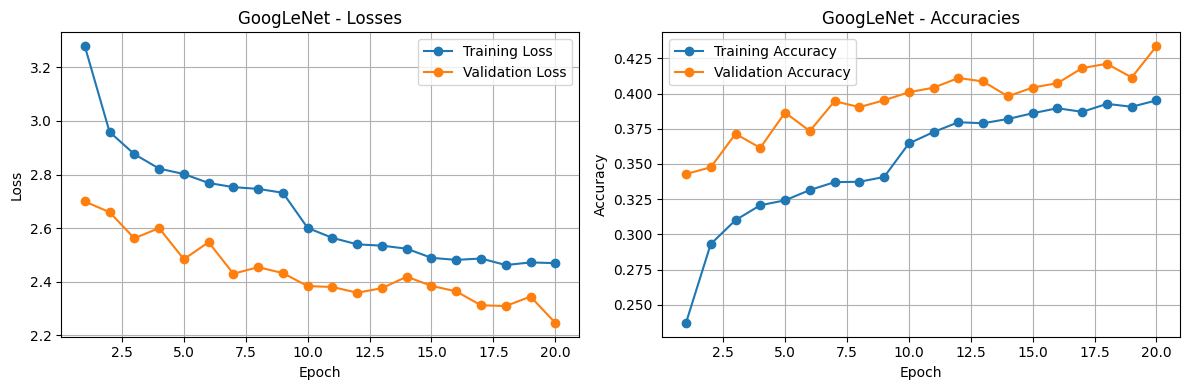


Loading best GoogLeNet weights from epoch with lowest val_loss...
Evaluating GoogLeNet on Test Dataset...


--> Test Loss: 2.0338 | Test Acc: 47.79%


Starting Training for ResNet


    ! Validation loss improved to 2.4064! Saved best model to /content/drive/MyDrive/94691/models-15-epochs/ResNet_best_food101.pth
Epoch [1/20] | Train Loss: 2.8519 | Train Acc: 31.85% | Val Loss: 2.4064 | Val Acc: 40.66% | LR: 0.010000


    ! Validation loss improved to 2.2844! Saved best model to /content/drive/MyDrive/94691/models-15-epochs/ResNet_best_food101.pth
Epoch [2/20] | Train Loss: 2.4682 | Train Acc: 39.22% | Val Loss: 2.2844 | Val Acc: 43.21% | LR: 0.010000


    ! Validation loss improved to 2.1950! Saved best model to /content/drive/MyDrive/94691/models-15-epochs/ResNet_best_food101.pth
Epoch [3/20] | Train Loss: 2.3807 | Train Acc: 41.13% | Val Loss: 2.1950 | Val Acc: 45.53% | LR: 0.010000


...

Epoch [15/20] | Train Loss: 1.8320 | Train Acc: 53.12% | Val Loss: 1.8638 | Val Acc: 52.56% | LR: 0.000400


Epoch [16/20] | Train Loss: 1.8391 | Train Acc: 52.82% | Val Loss: 1.8961 | Val Acc: 51.84% | LR: 0.000080


Epoch [17/20] | Train Loss: 1.8413 | Train Acc: 52.82% | Val Loss: 1.8824 | Val Acc: 52.42% | LR: 0.000080


Epoch [18/20] | Train Loss: 1.8289 | Train Acc: 53.07% | Val Loss: 1.9189 | Val Acc: 51.64% | LR: 0.000016


Early stopping triggered!


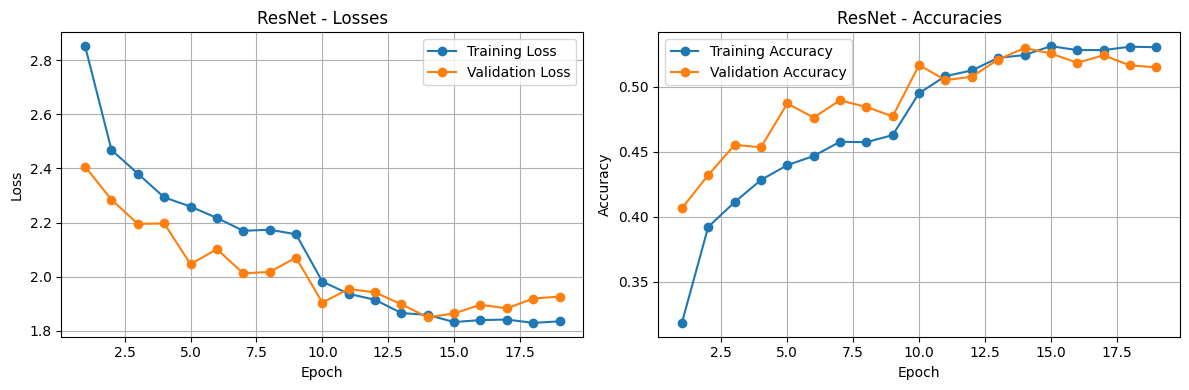


Loading best ResNet weights from epoch with lowest val_loss...
Evaluating ResNet on Test Dataset...


--> Test Loss: 1.5798 | Test Acc: 58.15%



In [80]:

model_names = [m.__class__.__name__ for m in models]
num_max_epochs = 20

save_path = '/content/drive/MyDrive/94691/models-15-epochs/'
os.makedirs(save_path, exist_ok=True)

for i, model in enumerate(models):
  print(f"\n{'='*40}")
  print(f"Starting Training for {model_names[i]}")
  print(f"{'='*40}")

  optimizer = optimizers[i]
  name = model_names[i]

  model_checkpoint_path = f"{save_path}{name}_best_food101.pth"

  # Instantiate Callback
  custom_callback = CustomCallback(
      early_stop_patience=5,
      reduce_lr_factor=0.2,
      reduce_lr_patience=1, # Was 3
      reduce_lr_min_lr=1e-6,
      checkpoint_path=model_checkpoint_path)
  custom_callback.set_optimizer(optimizer)
  custom_callback.set_model(model)
  custom_callback.on_train_begin()

  # Histories for THIS model
  train_losses, train_accuracies = [], []
  val_losses, val_accuracies = [], []

  # Train and Validate
  for epoch in range(num_max_epochs):
    train_loss, train_acc = trainOneEpoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validateOneEpoch(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # Check for early stopping using the custom callback and adjust learning rate.
    if custom_callback.on_epoch_end(epoch, val_loss):
        break

    print(f"Epoch [{epoch + 1}/{num_max_epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2%} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2%} | "
          f"LR: {optimizer.param_groups[0]['lr']:.6f}")

  # Plot the 2 charts for THIS model
  plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, model_names[i])

  # Load the best weights before running the test!
  print(f"\nLoading best {name} weights from epoch with lowest val_loss...")
  model.load_state_dict(torch.load(model_checkpoint_path))


  # Finally, evaluate this model on the unseen Test Dataset
  print(f"Evaluating {model_names[i]} on Test Dataset...")
  test_loss, test_acc = validateOneEpoch(model, test_loader, criterion, device)
  print(f"--> Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2%}\n")

In [81]:
# Create a folder in my Google Drive for the weights
save_path = '/content/drive/MyDrive/94691/models-15-epochs-jin/'
lr=0.01
os.makedirs(save_path, exist_ok=True)

for i, model in enumerate(models):
    name = model_names[i]
    # Save the weights (.pth is the standard extension)
    torch.save(model.state_dict(), f"{save_path}{name}_food101_{lr}_last.pth")
    print(f"Saved {name} weights to Google Drive.")

Saved MobileNetV3 weights to Google Drive.
Saved GoogLeNet weights to Google Drive.
Saved ResNet weights to Google Drive.


# Additional evaluation

MobileNetV3 is finishing training with the highest accuracy, but it still achieves only 58% accuracy on the test set.

Where is the model struggling the most?

In [ ]:
# Reload best model

# 1. Initialize the model and load the best weights from disk
print("Loading best model for error analysis...")
best_weights_path = "/content/drive/MyDrive/94691/models-15-epochs/MobileNetV3_best_food101_LR0.001.pth"

# Recreate the model architecture
analysis_model = torchvision.models.mobilenet_v3_large(weights=None)
analysis_model.classifier = nn.Sequential(
    nn.Linear(960, 1024), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(1024, 512), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(512, 101),
)

# Load the weights and move to GPU
analysis_model.load_state_dict(torch.load(best_weights_path, map_location=device))
analysis_model.to(device)
analysis_model.eval()

# 2. Collect all predictions and true labels from the Test Set
all_preds = []
all_labels = []

# Restart data loader:
test_loader = DataLoader(
    test_dataset_clean,
    batch_size=batch_size,
    num_workers=2,
    shuffle=False,
    pin_memory=True,
    persistent_workers=False
)

print("Running test set evaluation... with progress")
with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images, labels = images.to(device), labels.to(device)
        images = gpu_eval_transforms(images)

        outputs = analysis_model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())



In [83]:
import numpy as np
from sklearn.metrics import confusion_matrix

# 3. Calculate Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# 4. Find the most confused pairs (ignoring the correct predictions on the diagonal)
# Create a copy of the CM and fill the diagonal with 0s so we only look at ERRORS
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

# Get the class names from the dataset
class_names = sorted(train_full.class_to_idx.keys())

# Flatten the error matrix and get the indices of the highest values
num_top_errors = 10
top_error_indices = np.argsort(cm_errors, axis=None)[-num_top_errors:][::-1]

print("\n" + "="*50)
print("TOP 10 MOST CONFUSED FOOD PAIRS")
print("="*50)

for idx in top_error_indices:
    true_class_idx = idx // 101
    pred_class_idx = idx % 101
    num_errors = cm_errors[true_class_idx, pred_class_idx]

    true_name = class_names[true_class_idx]
    pred_name = class_names[pred_class_idx]

    print(f"Actual: {true_name:>25}  -->  Predicted: {pred_name:<25} ({num_errors} times)")


TOP 10 MOST CONFUSED FOOD PAIRS
Actual:                  tiramisu  -->  Predicted: chocolate_cake            (42 times)
Actual:              tuna_tartare  -->  Predicted: beef_tartare              (40 times)
Actual:                     ramen  -->  Predicted: pho                       (39 times)
Actual:                bruschetta  -->  Predicted: caprese_salad             (39 times)
Actual:                 hamburger  -->  Predicted: pulled_pork_sandwich      (35 times)
Actual:                 pork_chop  -->  Predicted: steak                     (34 times)
Actual:                     steak  -->  Predicted: filet_mignon              (32 times)
Actual:   grilled_cheese_sandwich  -->  Predicted: club_sandwich             (32 times)
Actual:              filet_mignon  -->  Predicted: steak                     (31 times)
Actual:                     steak  -->  Predicted: baby_back_ribs            (31 times)


In [ ]:
# Normalize the submatrix by row totals (percentage of actual class)
cm_sub_pct = cm_sub.astype(float)
row_sums = cm[np.ix_(sub_indices, range(101))].sum(axis=1, keepdims=True)  # total predictions per class
cm_sub_pct = cm_sub_pct / row_sums * 100

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_sub_pct, cmap='Blues', vmin=0, vmax=100)
plt.colorbar(im, label='%')

# Add percentage annotations
for i in range(len(sub_indices)):
    for j in range(len(sub_indices)):
        val = cm_sub_pct[i, j]
        color = 'white' if val > 50 else 'black'
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center', color=color, fontsize=9)

ax.set_xticks(range(len(sub_names)))
ax.set_xticklabels(sub_names, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(sub_names)))
ax.set_yticklabels(sub_names, fontsize=10)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (%) — "{worst_name}" vs Top {top_n} Misclassifications')
plt.tight_layout()
plt.show()

Let's see some example. We need to calculate the image indicates again:


In [ ]:
import random

# 1. Collect predictions with image indices
all_preds = []
all_labels = []
all_indices = []

with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(tqdm(test_loader)):
        images, labels = images.to(device), labels.to(device)
        images = gpu_eval_transforms(images)
        outputs = analysis_model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        # Track the original dataset index for each sample
        start = batch_idx * batch_size
        all_indices.extend(range(start, start + len(labels)))

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_indices = np.array(all_indices)


In [ ]:
from PIL import Image

def pad_to_square(img, size=224):
    """Pad image to square and resize to uniform size."""
    if not isinstance(img, Image.Image):
        img = Image.fromarray(img)

    w, h = img.size
    max_dim = max(w, h)

    # Create square canvas with gray background
    padded = Image.new('RGB', (max_dim, max_dim), (200, 200, 200))
    padded.paste(img, ((max_dim - w) // 2, (max_dim - h) // 2))

    # Resize to uniform size
    padded = padded.resize((size, size), Image.BILINEAR)
    return np.array(padded)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for row, cls_idx in enumerate(chosen_classes):
    mask = all_labels == cls_idx
    cls_preds = all_preds[mask]
    cls_indices = all_indices[mask]

    correct_mask = cls_preds == cls_idx
    wrong_mask = cls_preds != cls_idx

    correct_idx = np.random.choice(cls_indices[correct_mask], 1)
    wrong_indices = np.random.choice(cls_indices[wrong_mask], 3, replace=False)
    samples = list(correct_idx) + list(wrong_indices)

    for col, sample_idx in enumerate(samples):
        img, label = test_dataset[sample_idx]
        pred_label = all_preds[sample_idx]

        img = pad_to_square(img, size=224)

        ax = axes[row, col]
        ax.imshow(img)
        ax.axis('off')

        if col == 0:
            ax.set_title(f'✓ {class_names[cls_idx]}', fontsize=10,
                         color='green', fontweight='bold')
        else:
            ax.set_title(f'✗ Pred: {class_names[pred_label]}', fontsize=10,
                         color='red', fontweight='bold')

    axes[row, 0].set_ylabel(class_names[cls_idx], fontsize=11,
                            fontweight='bold', rotation=0, labelpad=90, va='center')

plt.suptitle('Correct Prediction vs Misclassifications', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()